# CINVIE 2026 — progressive adoption of residential PV and PV+BESS in Punta Arenas

This notebook is a **2025-only, single-node** assessment for the CINVIE extended abstract.

Instead of assuming PV+BESS adoption from the beginning, the analysis represents a **progressive residential adoption pathway**:

- early stage: PV-only adoption;
- intermediate stages: increasing PV penetration with BESS adopted by a subset of PV households;
- high stage: large-scale PV adoption with substantial BESS participation.

The model keeps the 2025 demand, generation fleet and weather fixed. Residential PV and BESS capacities are imposed **exogenously**; PyPSA optimises dispatch only.

### Household technology assumptions
- PV: **5 kW per PV household**
- BESS: **5 kW / 10 kWh per BESS household**
- Approximate Punta Arenas household denominator: **49,571 households**
- Model/weather year: **2025**
- No CO₂ cap, H₂, PtX, heat module or endogenous expansion

PV-only counterfactuals are also simulated at the PV penetration levels where BESS is introduced, allowing the incremental system-level effect of storage to be isolated.


## 1. Imports and workflow controls

In [34]:
from pathlib import Path
import gc
import importlib

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
from IPython.display import display

import config

config = importlib.reload(config)
config.configure_runtime_output()


In [40]:
# ── Workflow controls ────────────────────────────────────────────────────────
# Set True now to add S5. Existing scenarios are skipped because OVERWRITE_RESULTS=False.
RUN_SIMULATIONS = True
OVERWRITE_RESULTS = True

# Model year and weather year: CINVIE is a 2025 snapshot.
MODEL_YEAR = 2025
WEATHER_YEAR = 2025

# Case inputs
CASE_FOLDER = "input_punta_arenas"
BASE_CASE_NAME = "punta_arenas_cinvie"
RESIDENTIAL_ZONE = "punta_arenas_centro"

# ERA5 / atlite
CUTOUT_CASE_NAME = "magallanes"
CUTOUT_FILE = f"{CUTOUT_CASE_NAME}_{WEATHER_YEAR}.nc"
VRE_PROFILE_METHOD = "atlite_technology"
WIND_TURBINE = "Vestas_V112_3MW"
SOLAR_PANEL = "CSi"
SOLAR_ORIENTATION = "latitude_optimal"

# Solver
SOLVER_NAME = "gurobi"
TIME_LIMIT = 2000
MIP_GAP = 0.02
THREADS = 4
FALLBACK_TO_HIGHS = False
PREPARE_CUTOUT = False

# CINVIE does not use these modules.
ENABLE_HEAT = False
ENABLE_HYDROGEN = False
ENABLE_PTX = False

# Output
OUTPUT_ROOT = Path("output") / "output_punta_arenas_cinvie"
TABLE_DIR = OUTPUT_ROOT / "tables"
FIGURE_DIR = OUTPUT_ROOT / "figures"
HOURLY_DIR = OUTPUT_ROOT / "hourly"

for folder in [OUTPUT_ROOT, TABLE_DIR, FIGURE_DIR, HOURLY_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

SUMMARY_CSV = TABLE_DIR / "cinvie_2025_adoption_pathway_summary.csv"

# ── Paper figure settings: aligned with the main Punta Arenas notebook ──────
PAPER_DPI = 300

CM_TO_INCH = 1 / 2.54
WORD_DOUBLE_COL_IN = 16.0 * CM_TO_INCH
FIGSIZE_2COL = (WORD_DOUBLE_COL_IN, 3.35)
FIGSIZE_PAPER_2X2 = (WORD_DOUBLE_COL_IN, 4.95)
FIGSIZE_2COL_LARGE = (7.2, 5.6)

FONT_SIZE_BASE = 9
FONT_SIZE_SMALL = 8
FONT_SIZE_LABEL = 9
FONT_SIZE_PANEL = 9

plt.rcParams.update({
    "font.size": FONT_SIZE_BASE,
    "axes.labelsize": FONT_SIZE_BASE,
    "axes.titlesize": FONT_SIZE_BASE,
    "xtick.labelsize": FONT_SIZE_SMALL,
    "ytick.labelsize": FONT_SIZE_SMALL,
    "legend.fontsize": FONT_SIZE_SMALL,
})

TECH_COLORS = {
    "wind": "#5bbcff",
    "solar": "#ffd54f",
    "solar_pv": "#ffd54f",
    "ocgt": "#b85c5c",
    "gas": "#b85c5c",
    "bess": "#9966cc",
    "slack": "#d32f2f",
}

DEMAND_COLOR = "#4c78a8"
GRID_ALPHA = 0.25


def panel_label(ax, label: str, x: float = 0.015, y: float = 0.965):
    ax.text(
        x, y, label,
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=FONT_SIZE_PANEL,
        fontweight="bold",
        bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.75, "pad": 1.5},
        zorder=20,
    )


def finish_axis(ax, xlabel=None, ylabel=None):
    if xlabel is not None:
        ax.set_xlabel(xlabel)
    if ylabel is not None:
        ax.set_ylabel(ylabel)
    ax.grid(True, axis="y", alpha=GRID_ALPHA)
    ax.tick_params(axis="both", labelsize=FONT_SIZE_SMALL)
    return ax


def save_paper_figure(fig, filename: str):
    path = FIGURE_DIR / filename
    fig.savefig(path, dpi=PAPER_DPI, bbox_inches="tight")
    print(f"Saved figure: {path}")
    return path


paths = config.get_case_paths(CASE_FOLDER)

print("Config:", Path(config.__file__).resolve())
print("Case folder:", CASE_FOLDER)
print("Output:", OUTPUT_ROOT)


Config: C:\Users\vse23\OneDrive - University of Canterbury\Vicente\Analysis\0_PyPSA-Isolated\model\config.py
Case folder: input_punta_arenas
Output: output\output_punta_arenas_cinvie


## 2. Progressive PV → PV+BESS adoption pathway

The main pathway is intentionally asymmetric: PV adoption occurs first, while BESS enters later and grows as PV penetration increases.

### Main pathway
- **S0:** Baseline
- **S1:** 5,000 PV households; no BESS
- **S2:** 10,000 PV households + 1,000 BESS households
- **S3:** 20,000 PV households + 5,000 BESS households
- **S4:** 40,000 PV households + 20,000 BESS households
- **S5:** 40,000 PV households + 40,000 BESS households

S5 is an **upper-bound full-storage-adoption sensitivity** at the same PV penetration as S4. The S4 → S5 comparison therefore isolates the effect of increasing BESS adoption from 50% to 100% among PV households.

For S2–S5, PV-only counterfactuals at equal PV penetration are used to isolate the incremental system-level value of storage.


In [41]:
# ── Household-system assumptions ─────────────────────────────────────────────
PV_KW_PER_HOME = 5.0
BESS_KW_PER_HOME = 5.0
BESS_KWH_PER_HOME = 10.0

# Censo 2024 household count used only to express adoption levels as percentages.
TOTAL_HOUSEHOLDS = 49_571


def _mw_from_homes(n_homes: int, kw_per_home: float) -> float:
    return n_homes * kw_per_home / 1_000.0


def _mwh_from_homes(n_homes: int, kwh_per_home: float) -> float:
    return n_homes * kwh_per_home / 1_000.0


def _scenario(
    code: str,
    label: str,
    pv_homes: int,
    bess_homes: int = 0,
    pathway_stage: str = "",
    is_pathway: bool = True,
    counterfactual_for: str = "",
) -> dict:
    if bess_homes > pv_homes:
        raise ValueError("BESS households cannot exceed PV households.")

    pv_mw = _mw_from_homes(pv_homes, PV_KW_PER_HOME)
    bess_mw = _mw_from_homes(bess_homes, BESS_KW_PER_HOME)
    bess_mwh = _mwh_from_homes(bess_homes, BESS_KWH_PER_HOME)

    return {
        "code": code,
        "label": label,
        "pathway_stage": pathway_stage,
        "is_pathway": is_pathway,
        "counterfactual_for": counterfactual_for,
        "pv_homes": int(pv_homes),
        "bess_homes": int(bess_homes),
        # Retained for compatibility with existing summary logic.
        "n_prosumers": int(pv_homes),
        "pv_penetration_pct": 100.0 * pv_homes / TOTAL_HOUSEHOLDS,
        "bess_share_of_pv_pct": (100.0 * bess_homes / pv_homes) if pv_homes > 0 else 0.0,
        "pv_mw": pv_mw,
        "bess_mw": bess_mw,
        "bess_mwh": bess_mwh,
    }


# ── Main adoption pathway ────────────────────────────────────────────────────
PATHWAY_SCENARIOS = [
    _scenario("BASE", "S0 — Baseline", 0, 0, pathway_stage="S0"),
    _scenario("S1_PV5000", "S1 — 5,000 PV", 5_000, 0, pathway_stage="S1"),
    _scenario(
        "S2_PV10000_BESS1000",
        "S2 — 10,000 PV + 1,000 BESS",
        10_000, 1_000, pathway_stage="S2"
    ),
    _scenario(
        "S3_PV20000_BESS5000",
        "S3 — 20,000 PV + 5,000 BESS",
        20_000, 5_000, pathway_stage="S3"
    ),
    _scenario(
        "S4_PV40000_BESS20000",
        "S4 — 40,000 PV + 20,000 BESS",
        40_000, 20_000, pathway_stage="S4"
    ),
    _scenario(
        "S5_PV40000_BESS40000",
        "S5 — 40,000 PV + 40,000 BESS",
        40_000, 40_000, pathway_stage="S5"
    ),
]

# ── PV-only counterfactuals at the BESS stages ───────────────────────────────
COUNTERFACTUAL_SCENARIOS = [
    _scenario(
        "CF_PV10000",
        "CF — 10,000 PV only",
        10_000, 0,
        is_pathway=False,
        counterfactual_for="S2_PV10000_BESS1000",
    ),
    _scenario(
        "CF_PV20000",
        "CF — 20,000 PV only",
        20_000, 0,
        is_pathway=False,
        counterfactual_for="S3_PV20000_BESS5000",
    ),
    _scenario(
        "CF_PV40000",
        "CF — 40,000 PV only",
        40_000, 0,
        is_pathway=False,
        counterfactual_for="S4_PV40000_BESS20000;S5_PV40000_BESS40000",
    ),
]

SCENARIOS = PATHWAY_SCENARIOS + COUNTERFACTUAL_SCENARIOS
SCENARIO_ORDER = [s["code"] for s in SCENARIOS]
SCENARIO_LABELS = {s["code"]: s["label"] for s in SCENARIOS}
PATHWAY_CODES = [s["code"] for s in PATHWAY_SCENARIOS]

scenario_table = pd.DataFrame(SCENARIOS)
display(
    scenario_table[
        [
            "code", "label", "pv_homes", "bess_homes",
            "pv_penetration_pct", "bess_share_of_pv_pct",
            "pv_mw", "bess_mw", "bess_mwh", "is_pathway"
        ]
    ].round(2)
)


,code,label,pv_homes,bess_homes,pv_penetration_pct,bess_share_of_pv_pct,pv_mw,bess_mw,bess_mwh,is_pathway
0,BASE,S0 — Baseline,0,0,0.00,0.0,0.0,0.0,0.0,True
1,S1_PV5000,"S1 — 5,000 PV",5000,0,10.09,0.0,25.0,0.0,0.0,True
2,S2_PV10000_BESS1000,"S2 — 10,000 PV + 1,000 BESS",10000,1000,20.17,10.0,50.0,5.0,10.0,True
3,S3_PV20000_BESS5000,"S3 — 20,000 PV + 5,000 BESS",20000,5000,40.35,25.0,100.0,25.0,50.0,True
4,S4_PV40000_BESS20000,"S4 — 40,000 PV + 20,000 BESS",40000,20000,80.69,50.0,200.0,100.0,200.0,True
5,S5_PV40000_BESS40000,"S5 — 40,000 PV + 40,000 BESS",40000,40000,80.69,100.0,200.0,200.0,400.0,True
6,CF_PV10000,"CF — 10,000 PV only",10000,0,20.17,0.0,50.0,0.0,0.0,False
7,CF_PV20000,"CF — 20,000 PV only",20000,0,40.35,0.0,100.0,0.0,0.0,False
8,CF_PV40000,"CF — 40,000 PV only",40000,0,80.69,0.0,200.0,0.0,0.0,False


## 3. Build a single-node fixed-capacity 2025 system

The source CSVs remain unchanged. For each scenario the notebook creates in-memory tables that:

1. keep only **fixed/existing assets available in 2025**;
2. aggregate those existing generators onto `punta_arenas_centro`;
3. remove all ordinary flexible/candidate generation and storage rows;
4. append a **fixed** residential PV asset when required;
5. append a **fixed 2-h BESS** asset only in PV+BESS scenarios.

Therefore the optimisation is a **dispatch problem with exogenous prosumer capacities**, not a capacity-expansion problem.


In [42]:
PV_TEMPLATE_ASSET_ID = "pv_residential_flexible_punta_arenas_centro"
CINVIE_PV_ASSET_ID = "pv_residential_cinvie_punta_arenas_centro"
CINVIE_BESS_ASSET_ID = "bess_2h_cinvie_punta_arenas_centro"


def _enabled_mask(df: pd.DataFrame) -> pd.Series:
    if "enabled" not in df.columns:
        return pd.Series(True, index=df.index)
    return df["enabled"].astype(str).str.strip().str.lower().isin(
        ["true", "1", "yes", "y"]
    )


def _fixed_2025_mask(df: pd.DataFrame) -> pd.Series:
    """Select fixed/existing assets commissioned no later than MODEL_YEAR."""
    ctype = (
        df.get("commissioning_type", pd.Series("", index=df.index))
        .astype(str)
        .str.strip()
        .str.lower()
    )
    fixed = ctype.isin(["fixed", "existing", "committed", "commissioned", "exogenous"])

    fixed_year = pd.to_numeric(
        df.get("fixed_commissioning_year", pd.Series(np.nan, index=df.index)),
        errors="coerce",
    )
    available_year = pd.to_numeric(
        df.get("available_from_year", pd.Series(np.nan, index=df.index)),
        errors="coerce",
    )

    year_ok = (
        (fixed_year.isna() | (fixed_year <= MODEL_YEAR))
        & (available_year.isna() | (available_year <= MODEL_YEAR))
    )
    return _enabled_mask(df) & fixed & year_ok


def build_cinvie_nodes() -> pd.DataFrame:
    """Return only the aggregated Punta Arenas electrical node."""
    nodes_df = config.load_nodes_from_csv(paths["csv_nodes"])
    if nodes_df is None or nodes_df.empty:
        raise ValueError("nodes.csv could not be loaded.")

    node = nodes_df[nodes_df["zone"].astype(str).eq(RESIDENTIAL_ZONE)].copy()
    if node.empty:
        raise KeyError(
            f"Node '{RESIDENTIAL_ZONE}' was not found in nodes.csv."
        )

    # Exactly one electrical node in CINVIE.
    return node.reset_index(drop=True)


def build_cinvie_inputs(scenario: dict):
    """Build fixed 2025 generator/storage tables for the single-node CINVIE case."""
    capacity_all = config.load_generator_capacity_from_csv(paths["csv_capacity"])
    storage_all = config.load_storage_capacity_from_csv(paths["csv_storage"])

    if capacity_all is None or capacity_all.empty:
        raise ValueError("generators_capacity.csv could not be loaded.")
    if storage_all is None:
        raise ValueError("storage_capacity.csv could not be loaded.")

    capacity_all = capacity_all.copy()
    storage_all = storage_all.copy()

    # Save the residential PV row only as a physical/template definition.
    pv_template_mask = capacity_all["asset_id"].astype(str).eq(PV_TEMPLATE_ASSET_ID)
    if not pv_template_mask.any():
        raise KeyError(
            f"Residential PV template '{PV_TEMPLATE_ASSET_ID}' "
            "was not found in generators_capacity.csv."
        )
    pv_template = capacity_all.loc[pv_template_mask].iloc[0].copy()

    # ── Existing 2025 generation only ──────────────────────────────────────
    # This deliberately removes every flexible/candidate expansion option.
    capacity_df = capacity_all.loc[_fixed_2025_mask(capacity_all)].copy()

    # Single-node aggregation: existing Cabo Negro/Punta Arenas assets are
    # electrically represented at the Punta Arenas node.
    capacity_df["zone"] = RESIDENTIAL_ZONE

    # ── Exogenous residential PV ───────────────────────────────────────────
    if float(scenario["pv_mw"]) > 0:
        pv_row = pv_template.copy()
        pv_row["asset_id"] = CINVIE_PV_ASSET_ID
        pv_row["generator"] = "pv_residential_cinvie"
        pv_row["zone"] = RESIDENTIAL_ZONE
        pv_row["technology"] = "solar"
        pv_row["cost_key"] = "solar_residential_new"
        pv_row["installed_capacity"] = float(scenario["pv_mw"])
        pv_row["p_min_mw"] = 0.0
        pv_row["available_from_year"] = MODEL_YEAR
        pv_row["earliest_commissioning_year"] = MODEL_YEAR
        pv_row["fixed_commissioning_year"] = MODEL_YEAR
        pv_row["commissioning_type"] = "fixed"
        pv_row["enabled"] = True
        capacity_df = pd.concat(
            [capacity_df, pd.DataFrame([pv_row])],
            ignore_index=True,
        )

    # ── Existing storage only ──────────────────────────────────────────────
    # There is currently no existing 2025 BESS; future BESS candidates are removed.
    storage_df = storage_all.loc[_fixed_2025_mask(storage_all)].copy()
    if not storage_df.empty:
        storage_df["zone"] = RESIDENTIAL_ZONE

    # ── Exogenous residential BESS ─────────────────────────────────────────
    if float(scenario["bess_mw"]) > 0:
        new_row = {column: np.nan for column in storage_all.columns}
        new_row.update({
            "asset_id": CINVIE_BESS_ASSET_ID,
            "storage": "bess_2h_cinvie",
            "zone": RESIDENTIAL_ZONE,
            "technology": "bess",
            "cost_key": "bess_2h",
            "installed_power_mw": float(scenario["bess_mw"]),
            "p_nom_max_mw": float(scenario["bess_mw"]),
            "max_hours": float(scenario["bess_mwh"]) / float(scenario["bess_mw"]),
            "available_from_year": MODEL_YEAR,
            "earliest_commissioning_year": MODEL_YEAR,
            "fixed_commissioning_year": MODEL_YEAR,
            "commissioning_type": "fixed",
            "enabled": True,
            "initial_soc_fraction": np.nan,
            "final_soc_fraction": np.nan,
            "cyclic_state_of_charge": True,
        })
        storage_df = pd.concat(
            [storage_df, pd.DataFrame([new_row])],
            ignore_index=True,
        )

    # Explicit safety checks: CINVIE must contain no expandable rows.
    if (
        capacity_df.get("commissioning_type", pd.Series(dtype=str))
        .astype(str).str.lower().isin(["flexible", "candidate", "extendable", "expandable", "endogenous"])
        .any()
    ):
        raise RuntimeError("Expandable generator row survived the CINVIE filter.")

    if (
        storage_df.get("commissioning_type", pd.Series(dtype=str))
        .astype(str).str.lower().isin(["flexible", "candidate", "extendable", "expandable", "endogenous"])
        .any()
    ):
        raise RuntimeError("Expandable storage row survived the CINVIE filter.")

    return capacity_df.reset_index(drop=True), storage_df.reset_index(drop=True)


# Preview the aggregated node and largest PV+BESS case.
nodes_preview = build_cinvie_nodes()
cap_preview, storage_preview = build_cinvie_inputs(SCENARIOS[-1])

display(nodes_preview)
display(cap_preview[[
    "asset_id", "generator", "zone", "technology", "cost_key",
    "installed_capacity", "commissioning_type"
]])
display(storage_preview[[
    "asset_id", "storage", "zone", "technology", "cost_key",
    "installed_power_mw", "max_hours", "commissioning_type"
]])


,zone,annual_mean_mw,annual_heat_mean_mw,existing_gas_boiler_mw,installed_heat_pump_mw,allow_heat_pump,heat_pump_cop,gas_boiler_efficiency,lat,lon,enabled
0,punta_arenas_centro,38,20,28,0,True,3,0.9,-53.163,-70.917,True


,asset_id,generator,zone,technology,cost_key,installed_capacity,commissioning_type
0,wind_existing_cabo_negro,wind_existing,punta_arenas_centro,wind,wind_existing,2.55,fixed
1,ocgt_existing_punta_arenas_centro,ocgt_existing,punta_arenas_centro,ocgt,ocgt_existing,80.00,fixed
2,pv_residential_cinvie_punta_arenas_centro,pv_residential_cinvie,punta_arenas_centro,solar,solar_residential_new,200.00,fixed


,asset_id,storage,zone,technology,cost_key,installed_power_mw,max_hours,commissioning_type


## 4. Run the 2025 single-node scenarios

Nine simulations define the complete sensitivity set:

- six scenarios in the main adoption pathway (S0–S5);
- three PV-only counterfactuals for the 10k, 20k and 40k PV penetration levels.

Each scenario uses the same 2025 demand and weather. The network contains only `punta_arenas_centro`.

All generation/storage capacities are fixed before optimisation, so PyPSA optimises **dispatch only**. No additional PV, wind or BESS can be built endogenously.

With `RUN_SIMULATIONS=True` and `OVERWRITE_RESULTS=False`, previously exported scenarios are skipped and only missing scenarios — currently S5 — are solved.


In [43]:
def _sum_generator_carrier(net, carrier: str) -> pd.Series:
    ids = net.generators.index[
        net.generators["carrier"].astype(str).str.lower().eq(carrier.lower())
    ].tolist()
    if not ids:
        return pd.Series(0.0, index=net.snapshots)
    return net.generators_t.p.reindex(columns=ids, fill_value=0.0).sum(axis=1)


def _sum_storage_power(net, carrier: str = "bess") -> pd.Series:
    ids = net.storage_units.index[
        net.storage_units["carrier"].astype(str).str.lower().eq(carrier.lower())
    ].tolist()
    if not ids:
        return pd.Series(0.0, index=net.snapshots)
    return net.storage_units_t.p.reindex(columns=ids, fill_value=0.0).sum(axis=1)


def _sum_storage_soc(net, carrier: str = "bess") -> pd.Series:
    ids = net.storage_units.index[
        net.storage_units["carrier"].astype(str).str.lower().eq(carrier.lower())
    ].tolist()
    if not ids:
        return pd.Series(0.0, index=net.snapshots)
    return net.storage_units_t.state_of_charge.reindex(columns=ids, fill_value=0.0).sum(axis=1)


def _annual_co2_tons(net) -> float:
    if "co2_emissions" not in net.carriers.columns:
        return 0.0

    carrier_ef = net.carriers["co2_emissions"].fillna(0.0)
    carrier = net.generators["carrier"].astype(str)
    efficiency = net.generators["efficiency"].replace(0, np.nan).fillna(1.0)
    ef_per_mwh_el = carrier.map(carrier_ef).fillna(0.0) / efficiency

    dispatch = net.generators_t.p.reindex(columns=net.generators.index, fill_value=0.0)
    return float(dispatch.multiply(ef_per_mwh_el, axis=1).to_numpy().sum())


def _solar_curtailment(net) -> tuple[float, float, float]:
    """Return available, dispatched and curtailed solar energy [MWh]."""
    ids = net.generators.index[
        net.generators["carrier"].astype(str).str.lower().eq("solar")
    ].tolist()

    if not ids:
        return 0.0, 0.0, 0.0

    p_nom = net.generators.loc[ids, "p_nom"].astype(float).copy()
    if "p_nom_opt" in net.generators.columns:
        p_nom = net.generators.loc[ids, "p_nom_opt"].fillna(p_nom).astype(float)

    p_max_pu = net.generators_t.p_max_pu.reindex(columns=ids)
    if p_max_pu.isna().any().any():
        raise ValueError("Solar p_max_pu is missing; curtailment cannot be calculated.")

    available = p_max_pu.multiply(p_nom, axis=1)
    dispatch = net.generators_t.p.reindex(columns=ids, fill_value=0.0).clip(lower=0.0)
    curtailed = (available - dispatch).clip(lower=0.0)

    return (
        float(available.to_numpy().sum()),
        float(dispatch.to_numpy().sum()),
        float(curtailed.to_numpy().sum()),
    )


def _capacity_by_carrier(net, carrier: str) -> float:
    ids = net.generators.index[
        net.generators["carrier"].astype(str).str.lower().eq(carrier.lower())
    ]
    if len(ids) == 0:
        return 0.0
    if "p_nom_opt" in net.generators.columns:
        vals = net.generators.loc[ids, "p_nom_opt"].fillna(net.generators.loc[ids, "p_nom"])
    else:
        vals = net.generators.loc[ids, "p_nom"]
    return float(vals.astype(float).sum())


def summarize_scenario(net, scenario: dict) -> tuple[dict, pd.DataFrame]:
    load = net.loads_t.p_set.sum(axis=1)
    wind = _sum_generator_carrier(net, "wind")
    solar = _sum_generator_carrier(net, "solar")
    thermal = _sum_generator_carrier(net, "ocgt")
    slack = _sum_generator_carrier(net, "slack")

    bess_p = _sum_storage_power(net, "bess")
    bess_discharge = bess_p.clip(lower=0.0)
    bess_charge = (-bess_p.clip(upper=0.0))
    bess_soc = _sum_storage_soc(net, "bess")

    solar_available_mwh, solar_dispatch_mwh, solar_curtailment_mwh = _solar_curtailment(net)

    ocgt_ids = net.generators.index[
        net.generators["carrier"].astype(str).str.lower().eq("ocgt")
    ].tolist()
    if ocgt_ids:
        ocgt_mc = net.generators.loc[ocgt_ids, "marginal_cost"].astype(float)
        thermal_operating_cost = float(
            net.generators_t.p[ocgt_ids].clip(lower=0.0).multiply(ocgt_mc, axis=1).to_numpy().sum()
        )
    else:
        thermal_operating_cost = 0.0

    annual_row = {
        **scenario,
        "year": MODEL_YEAR,
        "weather_year": WEATHER_YEAR,
        "objective_usd": float(net.objective),
        "demand_mwh": float(load.sum()),
        "peak_demand_mw": float(load.max()),
        "wind_generation_mwh": float(wind.sum()),
        "solar_generation_mwh": float(solar.sum()),
        "thermal_generation_mwh": float(thermal.sum()),
        "slack_mwh": float(slack.sum()),
        "bess_charge_mwh": float(bess_charge.sum()),
        "bess_discharge_mwh": float(bess_discharge.sum()),
        "solar_available_mwh": solar_available_mwh,
        "solar_curtailment_mwh": solar_curtailment_mwh,
        "solar_curtailment_pct": (
            100.0 * solar_curtailment_mwh / solar_available_mwh
            if solar_available_mwh > 0 else 0.0
        ),
        "co2_tons": _annual_co2_tons(net),
        "thermal_operating_cost_usd": thermal_operating_cost,
        "installed_wind_mw": _capacity_by_carrier(net, "wind"),
        "installed_solar_mw": _capacity_by_carrier(net, "solar"),
        "installed_bess_mw": float(
            net.storage_units.loc[
                net.storage_units["carrier"].astype(str).str.lower().eq("bess"),
                "p_nom",
            ].astype(float).sum()
        ) if len(net.storage_units) else 0.0,
    }

    hourly = pd.DataFrame({
        "demand_mw": load,
        "wind_mw": wind,
        "solar_mw": solar,
        "thermal_mw": thermal,
        "slack_mw": slack,
        "bess_charge_mw": bess_charge,
        "bess_discharge_mw": bess_discharge,
        "bess_soc_mwh": bess_soc,
    }, index=pd.DatetimeIndex(net.snapshots))
    hourly.index.name = "timestamp"

    return annual_row, hourly


In [44]:
def run_all_cinvie_scenarios():
    rows = []

    for scenario in SCENARIOS:
        code = scenario["code"]
        hourly_path = HOURLY_DIR / f"{code}_2025.csv"

        if (
            not OVERWRITE_RESULTS
            and hourly_path.exists()
            and SUMMARY_CSV.exists()
        ):
            existing = pd.read_csv(SUMMARY_CSV)
            hit = existing[existing["code"].astype(str).eq(code)]
            if not hit.empty:
                print(f"Skipping existing scenario: {code}")
                rows.append(hit.iloc[-1].to_dict())
                continue

        print(
            f"\n=== {scenario['label']} | "
            f"PV={scenario['pv_mw']:.1f} MW | "
            f"BESS={scenario['bess_mw']:.1f} MW / {scenario['bess_mwh']:.1f} MWh ==="
        )

        nodes_df = build_cinvie_nodes()
        capacity_df, storage_df = build_cinvie_inputs(scenario)

        result = config.run_case(
            year=MODEL_YEAR,
            weather_year=WEATHER_YEAR,
            case_name=f"{BASE_CASE_NAME}_{code}",
            solver_name=SOLVER_NAME,
            vre_profile_method=VRE_PROFILE_METHOD,
            wind_turbine=WIND_TURBINE,
            solar_panel=SOLAR_PANEL,
            solar_orientation=SOLAR_ORIENTATION,
            time_limit=TIME_LIMIT,
            mip_gap=MIP_GAP,
            threads=THREADS,
            prepare_cutout=PREPARE_CUTOUT,
            fallback_to_highs=FALLBACK_TO_HIGHS,
            co2_cap_tons=None,
            enable_hydrogen=ENABLE_HYDROGEN,
            enable_heat=ENABLE_HEAT,
            enable_ptx=ENABLE_PTX,
            nodes_df=nodes_df,
            capacity_df=capacity_df,
            storage_df=storage_df,
            csv_nodes=paths["csv_nodes"],
            csv_interlinks=paths["csv_interlinks"],
            csv_capacity=paths["csv_capacity"],
            csv_storage=paths["csv_storage"],
            csv_hydro_assets=paths["csv_hydro_assets"],
            csv_hydro_inflows=paths["csv_hydro_inflows"],
            csv_hydrogen=paths["csv_hydrogen"],
            csv_ptx_assets=paths["csv_ptx_assets"],
            csv_ptx_monthly_demand=paths["csv_ptx_monthly_demand"],
            csv_costs=paths["csv_costs"],
            csv_general=paths["csv_general"],
            csv_demand=paths["csv_demand"],
            csv_demand_summary=paths["csv_demand_summary"],
            cutout_file=CUTOUT_FILE,
        )

        net = result["network"]
        row, hourly = summarize_scenario(net, scenario)
        rows.append(row)
        hourly.to_csv(hourly_path)

        # Update summary after every completed scenario.
        summary = pd.DataFrame(rows)
        summary.to_csv(SUMMARY_CSV, index=False)

        del hourly
        del net
        result.clear()
        gc.collect()

    return pd.DataFrame(rows)


if RUN_SIMULATIONS:
    scenario_summary = run_all_cinvie_scenarios()
else:
    if not SUMMARY_CSV.exists():
        raise FileNotFoundError(
            f"{SUMMARY_CSV} does not exist. Set RUN_SIMULATIONS=True and run this cell."
        )
    scenario_summary = pd.read_csv(SUMMARY_CSV)

scenario_summary["code"] = pd.Categorical(
    scenario_summary["code"],
    categories=SCENARIO_ORDER,
    ordered=True,
)
scenario_summary = scenario_summary.sort_values("code").reset_index(drop=True)

display(scenario_summary)



=== S0 — Baseline | PV=0.0 MW | BESS=0.0 MW / 0.0 MWh ===


c:\Users\vse23\AppData\Local\anaconda3\envs\pypsa-isolated\Lib\site-packages\atlite\cutout.py:156: UserWarning:

Arguments module, x, y, time, dx, dy are ignored, since cutout is already built.

c:\Users\vse23\AppData\Local\anaconda3\envs\pypsa-isolated\Lib\site-packages\atlite\resource.py:90: FutureWarning:

'add_cutout_windspeed' for wind turbine
power curves will default to True in atlite relase v0.2.15.

INFO:atlite.convert:Convert and aggregate 'wind'.
INFO:atlite.convert:Convert and aggregate 'pv'.
c:\Users\vse23\OneDrive - University of Canterbury\Vicente\Analysis\0_PyPSA-Isolated\model\config.py:4903: FutureWarning:

The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.

Writing continuous variables.: 100%|██████████| 1/1 [00:00<00:00, 148.99it/s]

Set parameter Username
Set parameter LicenseID to value 2807461
Academic license - for non-commercial use only - expires 2027-04-15
Read LP format model from file C:\Users\vse23\AppData\Local\Temp\linopy-problem-r9776mr3.lp


Reading time = 0.14 seconds
obj: 61320 rows, 26280 columns, 78840 nonzeros
Set parameter LogToConsole to value 1
Set parameter TimeLimit to value 2000
Set parameter MIPGap to value 0.02
Set parameter Threads to value 4
Set parameter OutputFlag to value 1
Set parameter LogToConsole to value 1
Set parameter Crossover to value 0
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 10.0 (19045.2))

CPU model: Intel(R) Core(TM) i5-8365U CPU @ 1.60GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 8 logical processors, using up to 4 threads

Non-default parameters:
TimeLimit  2000
MIPGap  0.02
Crossover  0
Threads  4

Optimize a model with 61320 rows, 26280 columns and 78840 nonzeros (Min)
Model fingerprint: 0xc0a4dd83
Model has 17520 linear objective coefficients
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [6e+01, 1e+05]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e-05, 1e+06]

Presolve removed 61320 rows and 26280 c

c:\Users\vse23\AppData\Local\anaconda3\envs\pypsa-isolated\Lib\site-packages\atlite\cutout.py:156: UserWarning:

Arguments module, x, y, time, dx, dy are ignored, since cutout is already built.

c:\Users\vse23\AppData\Local\anaconda3\envs\pypsa-isolated\Lib\site-packages\atlite\resource.py:90: FutureWarning:

'add_cutout_windspeed' for wind turbine
power curves will default to True in atlite relase v0.2.15.

INFO:atlite.convert:Convert and aggregate 'wind'.
INFO:atlite.convert:Convert and aggregate 'pv'.
c:\Users\vse23\OneDrive - University of Canterbury\Vicente\Analysis\0_PyPSA-Isolated\model\config.py:4903: FutureWarning:

The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.

Writing continuous variables.: 100%|██████████| 1/1 [00:00<00:00, 127.39it/s]

...

Reading time = 0.18 seconds
obj: 78840 rows, 35040 columns, 105120 nonzeros
Set parameter LogToConsole to value 1
Set parameter TimeLimit to value 2000
Set parameter MIPGap to value 0.02
Set parameter Threads to value 4
Set parameter OutputFlag to value 1
Set parameter LogToConsole to value 1
Set parameter Crossover to value 0
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 10.0 (19045.2))

CPU model: Intel(R) Core(TM) i5-8365U CPU @ 1.60GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 8 logical processors, using up to 4 threads

Non-default parameters:
TimeLimit  2000
MIPGap  0.02
Crossover  0
Threads  4

Optimize a model with 78840 rows, 35040 columns and 105120 nonzeros (Min)
Model fingerprint: 0x4fae6a2c
Model has 17520 linear objective coefficients
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [6e+01, 1e+05]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e-05, 1e+06]

Presolve removed 78840 rows and 35040

c:\Users\vse23\AppData\Local\anaconda3\envs\pypsa-isolated\Lib\site-packages\atlite\cutout.py:156: UserWarning:

Arguments module, x, y, time, dx, dy are ignored, since cutout is already built.

c:\Users\vse23\AppData\Local\anaconda3\envs\pypsa-isolated\Lib\site-packages\atlite\resource.py:90: FutureWarning:

'add_cutout_windspeed' for wind turbine
power curves will default to True in atlite relase v0.2.15.

INFO:atlite.convert:Convert and aggregate 'wind'.
INFO:atlite.convert:Convert and aggregate 'pv'.
c:\Users\vse23\OneDrive - University of Canterbury\Vicente\Analysis\0_PyPSA-Isolated\model\config.py:4903: FutureWarning:

The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.

Writing continuous variables.: 100%|██████████| 1/1 [00:00<00:00, 55.33it/s]

Set parameter Username
Set parameter LicenseID to value 2807461
Academic license - for non-commercial use only - expires 2027-04-15


Read LP format model from file C:\Users\vse23\AppData\Local\Temp\linopy-problem-c7__5a4t.lp
Reading time = 0.20 seconds
obj: 78840 rows, 35040 columns, 105120 nonzeros
Set parameter LogToConsole to value 1
Set parameter TimeLimit to value 2000
Set parameter MIPGap to value 0.02
Set parameter Threads to value 4
Set parameter OutputFlag to value 1
Set parameter LogToConsole to value 1
Set parameter Crossover to value 0
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 10.0 (19045.2))

CPU model: Intel(R) Core(TM) i5-8365U CPU @ 1.60GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 8 logical processors, using up to 4 threads

Non-default parameters:
TimeLimit  2000
MIPGap  0.02
Crossover  0
Threads  4

Optimize a model with 78840 rows, 35040 columns and 105120 nonzeros (Min)
Model fingerprint: 0xe8bc3229
Model has 17520 linear objective coefficients
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [6e+01, 1e+05]
  Bounds range

,code,label,pathway_stage,is_pathway,counterfactual_for,pv_homes,bess_homes,n_prosumers,pv_penetration_pct,bess_share_of_pv_pct,...,bess_charge_mwh,bess_discharge_mwh,solar_available_mwh,solar_curtailment_mwh,solar_curtailment_pct,co2_tons,thermal_operating_cost_usd,installed_wind_mw,installed_solar_mw,installed_bess_mw
0,BASE,S0 — Baseline,S0,True,,0,0,0,0.000000,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,140960.459268,1.474257e+07,2.55,0.0,0.0
1,S1_PV5000,"S1 — 5,000 PV",S1,True,,5000,0,5000,10.086543,0.0,...,0.000000,0.000000,28777.753819,0.000000,0.000000,125662.811186,1.314264e+07,2.55,25.0,0.0
2,S2_PV10000_BESS1000,"S2 — 10,000 PV + 1,000 BESS",S2,True,,10000,1000,10000,20.173085,10.0,...,681.756639,606.230057,57555.507638,346.424716,0.601897,110684.294706,1.157609e+07,2.55,50.0,5.0
3,S3_PV20000_BESS5000,"S3 — 20,000 PV + 5,000 BESS",S3,True,,20000,5000,20000,40.346170,25.0,...,11870.582328,10527.753232,115111.015275,15498.755484,13.464181,89693.554278,9.380738e+06,2.55,100.0,25.0
4,S4_PV40000_BESS20000,"S4 — 40,000 PV + 20,000 BESS",S4,True,,40000,20000,40000,80.692340,50.0,...,57662.680441,52040.569098,230222.030550,64012.641047,27.804742,56714.507304,5.931574e+06,2.55,200.0,100.0
5,S5_PV40000_BESS40000,"S5 — 40,000 PV + 40,000 BESS",S5,True,,40000,40000,40000,80.692340,100.0,...,87982.760631,79404.441469,230222.030550,34669.985454,15.059369,42168.448833,4.410252e+06,2.55,200.0,200.0
6,CF_PV10000,"CF — 10,000 PV only",,False,S2_PV10000_BESS1000,10000,0,10000,20.173085,0.0,...,0.000000,0.000000,57555.507638,774.758522,1.346107,111000.291053,1.160914e+07,2.55,50.0,0.0
7,CF_PV20000,"CF — 20,000 PV only",,False,S3_PV20000_BESS5000,20000,0,20000,40.346170,0.0,...,0.000000,0.000000,115111.015275,26626.731359,23.131350,95271.876769,9.964155e+06,2.55,100.0,0.0
8,CF_PV40000,"CF — 40,000 PV only",,False,S4_PV40000_BESS20000;S5_PV40000_BESS40000,40000,0,40000,80.692340,0.0,...,0.000000,0.000000,230222.030550,119766.527501,52.022184,84378.178246,8.824821e+06,2.55,200.0,0.0


## 5. System-impact summary

The table reports the main technical and operating-cost effects relative to the 2025 baseline.

The adoption-pathway scenarios and PV-only counterfactuals are kept in the same summary file so the contribution of BESS can later be isolated at equal PV penetration.


In [45]:
summary = scenario_summary.copy()
baseline = summary[summary["code"].astype(str).eq("BASE")].iloc[0]

summary["thermal_reduction_mwh"] = (
    baseline["thermal_generation_mwh"] - summary["thermal_generation_mwh"]
)
summary["thermal_reduction_pct"] = np.where(
    baseline["thermal_generation_mwh"] > 0,
    100.0 * summary["thermal_reduction_mwh"] / baseline["thermal_generation_mwh"],
    np.nan,
)

summary["co2_reduction_tons"] = baseline["co2_tons"] - summary["co2_tons"]
summary["co2_reduction_pct"] = np.where(
    baseline["co2_tons"] > 0,
    100.0 * summary["co2_reduction_tons"] / baseline["co2_tons"],
    np.nan,
)

summary["objective_change_usd"] = summary["objective_usd"] - baseline["objective_usd"]
summary["thermal_cost_saving_usd"] = (
    baseline["thermal_operating_cost_usd"] - summary["thermal_operating_cost_usd"]
)

summary["bess_throughput_mwh"] = (
    summary["bess_charge_mwh"] + summary["bess_discharge_mwh"]
)

columns_to_show = [
    "code",
    "label",
    "pv_homes",
    "bess_homes",
    "pv_penetration_pct",
    "bess_share_of_pv_pct",
    "pv_mw",
    "bess_mw",
    "bess_mwh",
    "thermal_generation_mwh",
    "thermal_reduction_pct",
    "co2_tons",
    "co2_reduction_pct",
    "solar_generation_mwh",
    "solar_curtailment_pct",
    "bess_charge_mwh",
    "bess_discharge_mwh",
    "bess_throughput_mwh",
    "thermal_operating_cost_usd",
    "thermal_cost_saving_usd",
    "slack_mwh",
]

display(summary[columns_to_show].round(2))
summary.to_csv(TABLE_DIR / "cinvie_2025_adoption_pathway_impacts.csv", index=False)


,code,label,pv_homes,bess_homes,pv_penetration_pct,bess_share_of_pv_pct,pv_mw,bess_mw,bess_mwh,thermal_generation_mwh,...,co2_tons,co2_reduction_pct,solar_generation_mwh,solar_curtailment_pct,bess_charge_mwh,bess_discharge_mwh,bess_throughput_mwh,thermal_operating_cost_usd,thermal_cost_saving_usd,slack_mwh
0,BASE,S0 — Baseline,0,0,0.00,0.0,0.0,0.0,0.0,265173.14,...,140960.46,0.00,0.00,0.00,0.00,0.00,0.00,14742565.96,0.00,0.0
1,S1_PV5000,"S1 — 5,000 PV",5000,0,10.09,0.0,25.0,0.0,0.0,236395.39,...,125662.81,10.85,28777.75,0.00,0.00,0.00,0.00,13142637.96,1599928.00,0.0
2,S2_PV10000_BESS1000,"S2 — 10,000 PV + 1,000 BESS",10000,1000,20.17,10.0,50.0,5.0,10.0,208217.98,...,110684.29,21.48,57209.08,0.60,681.76,606.23,1287.99,11576086.82,3166479.13,0.0
3,S3_PV20000_BESS5000,"S3 — 20,000 PV + 5,000 BESS",20000,5000,40.35,25.0,100.0,25.0,50.0,168730.45,...,89693.55,36.37,99612.26,13.46,11870.58,10527.75,22398.34,9380738.02,5361827.94,0.0
4,S4_PV40000_BESS20000,"S4 — 40,000 PV + 20,000 BESS",40000,20000,80.69,50.0,200.0,100.0,200.0,106690.66,...,56714.51,59.77,166209.39,27.80,57662.68,52040.57,109703.25,5931573.78,8810992.17,0.0
5,S5_PV40000_BESS40000,"S5 — 40,000 PV + 40,000 BESS",40000,40000,80.69,100.0,200.0,200.0,400.0,79326.78,...,42168.45,70.08,195552.05,15.06,87982.76,79404.44,167387.20,4410251.94,10332314.02,0.0
6,CF_PV10000,"CF — 10,000 PV only",10000,0,20.17,0.0,50.0,0.0,0.0,208812.43,...,111000.29,21.25,56780.75,1.35,0.00,0.00,0.00,11609135.79,3133430.17,0.0
7,CF_PV20000,"CF — 20,000 PV only",20000,0,40.35,0.0,100.0,0.0,0.0,179224.32,...,95271.88,32.41,88484.28,23.13,0.00,0.00,0.00,9964155.44,4778410.52,0.0
8,CF_PV40000,"CF — 40,000 PV only",40000,0,80.69,0.0,200.0,0.0,0.0,158731.23,...,84378.18,40.14,110455.50,52.02,0.00,0.00,0.00,8824821.26,5917744.69,0.0


## 6. Main adoption-pathway figure

S0–S5 are shown in the main figure. The colours follow the same technology palette used in the main Punta Arenas paper: **wind = light blue, solar = yellow, gas = muted red, BESS = purple**.

S5 keeps PV fixed at the S4 level and doubles BESS adoption from 20,000 to 40,000 households, providing an upper-bound storage sensitivity.


Saved figure: output\output_punta_arenas_cinvie\figures\cinvie_2025_adoption_pathway_system_impacts.png


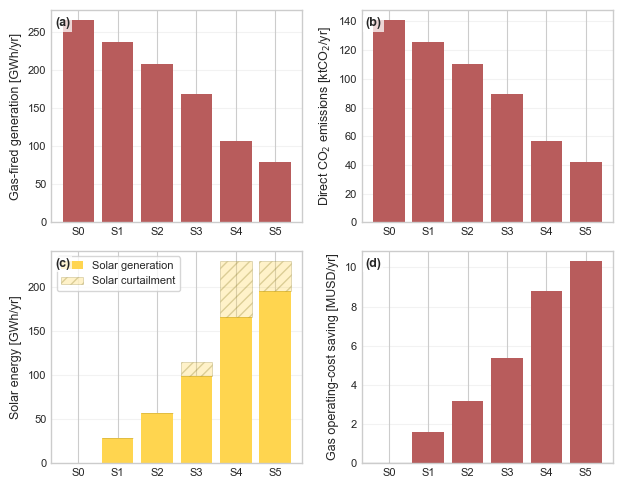

,pathway_stage,pv_homes,bess_homes,pv_penetration_pct,bess_share_of_pv_pct,pv_mw,bess_mw,bess_mwh
0,S0,0,0,0.0,0.0,0.0,0.0,0.0
1,S1,5000,0,10.1,0.0,25.0,0.0,0.0
2,S2,10000,1000,20.2,10.0,50.0,5.0,10.0
3,S3,20000,5000,40.3,25.0,100.0,25.0,50.0
4,S4,40000,20000,80.7,50.0,200.0,100.0,200.0
5,S5,40000,40000,80.7,100.0,200.0,200.0,400.0


In [46]:
plot_df = summary[summary["code"].astype(str).isin(PATHWAY_CODES)].copy()
plot_df["_order"] = plot_df["code"].astype(str).map(
    {code: i for i, code in enumerate(PATHWAY_CODES)}
)
plot_df = plot_df.sort_values("_order")

labels = plot_df["pathway_stage"].astype(str).tolist()
x = np.arange(len(plot_df))

fig, axes = plt.subplots(2, 2, figsize=FIGSIZE_PAPER_2X2)

# (a) Gas-fired generation
axes[0, 0].bar(
    x,
    plot_df["thermal_generation_mwh"] / 1e3,
    color=TECH_COLORS["gas"],
)
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(labels)
finish_axis(axes[0, 0], ylabel="Gas-fired generation [GWh/yr]")
panel_label(axes[0, 0], "(a)")

# (b) Direct CO2 emissions
axes[0, 1].bar(
    x,
    plot_df["co2_tons"] / 1e3,
    color=TECH_COLORS["gas"],
)
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(labels)
finish_axis(axes[0, 1], ylabel="Direct CO$_2$ emissions [ktCO$_2$/yr]")
panel_label(axes[0, 1], "(b)")

# (c) Solar generation and curtailment
solar_gen = plot_df["solar_generation_mwh"] / 1e3
solar_curt = plot_df["solar_curtailment_mwh"] / 1e3

axes[1, 0].bar(
    x,
    solar_gen,
    color=TECH_COLORS["solar"],
    label="Solar generation",
)
axes[1, 0].bar(
    x,
    solar_curt,
    bottom=solar_gen,
    color=TECH_COLORS["solar"],
    alpha=0.30,
    hatch="///",
    edgecolor="#8a7a20",
    linewidth=0.6,
    label="Solar curtailment",
)
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(labels)
finish_axis(axes[1, 0], ylabel="Solar energy [GWh/yr]")
axes[1, 0].legend(frameon=True, loc="upper left")
panel_label(axes[1, 0], "(c)")

# (d) Avoided gas operating cost
axes[1, 1].bar(
    x,
    plot_df["thermal_cost_saving_usd"] / 1e6,
    color=TECH_COLORS["gas"],
)
axes[1, 1].axhline(0, linewidth=0.8, color="0.25")
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(labels)
finish_axis(axes[1, 1], ylabel="Gas operating-cost saving [MUSD/yr]")
panel_label(axes[1, 1], "(d)")

fig.tight_layout()
save_paper_figure(fig, "cinvie_2025_adoption_pathway_system_impacts.png")
plt.show()

# Compact scenario key for manuscript/figure caption
scenario_key = plot_df[
    [
        "pathway_stage",
        "pv_homes",
        "bess_homes",
        "pv_penetration_pct",
        "bess_share_of_pv_pct",
        "pv_mw",
        "bess_mw",
        "bess_mwh",
    ]
].copy()

display(scenario_key.round(1))
scenario_key.to_csv(
    TABLE_DIR / "cinvie_2025_pathway_scenario_key.csv",
    index=False,
)


## 7. Incremental value of BESS at equal PV penetration

The pathway scenarios are compared against PV-only counterfactuals at the **same PV penetration**:

- 10,000 PV: 0 vs 1,000 BESS households;
- 20,000 PV: 0 vs 5,000 BESS households;
- 40,000 PV: 0 vs 20,000 BESS households;
- 40,000 PV: 0 vs 40,000 BESS households.

The last two comparisons show how the marginal value of storage changes when BESS adoption rises from 50% to 100% among households already equipped with PV.


,pv_homes,bess_homes,pv_mw,bess_mw,bess_mwh,gas_generation_pv_gwh,gas_generation_pvbess_gwh,additional_gas_reduction_from_bess_gwh,co2_pv_kt,co2_pvbess_kt,additional_co2_reduction_from_bess_kt,curtailment_pv_pct,curtailment_pvbess_pct,curtailment_reduction_pp,bess_charge_gwh,bess_discharge_gwh
0,10000,1000,50.0,5.0,10.0,208.812,208.218,0.594,111.000,110.684,0.316,1.346,0.602,0.744,0.682,0.606
1,20000,5000,100.0,25.0,50.0,179.224,168.730,10.494,95.272,89.694,5.578,23.131,13.464,9.667,11.871,10.528
2,40000,20000,200.0,100.0,200.0,158.731,106.691,52.041,84.378,56.715,27.664,52.022,27.805,24.217,57.663,52.041
3,40000,40000,200.0,200.0,400.0,158.731,79.327,79.404,84.378,42.168,42.210,52.022,15.059,36.963,87.983,79.404


Saved figure: output\output_punta_arenas_cinvie\figures\cinvie_2025_incremental_bess_value.png


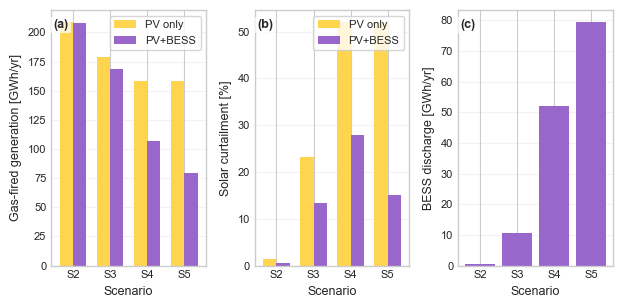

In [51]:
BESS_COMPARISONS = [
    ("CF_PV10000", "S2_PV10000_BESS1000", 10_000, 1_000),
    ("CF_PV20000", "S3_PV20000_BESS5000", 20_000, 5_000),
    ("CF_PV40000", "S4_PV40000_BESS20000", 40_000, 20_000),
    ("CF_PV40000", "S5_PV40000_BESS40000", 40_000, 40_000),
]

pair_rows = []

for pv_code, pvb_code, pv_homes, bess_homes in BESS_COMPARISONS:
    pv = summary[summary["code"].astype(str).eq(pv_code)].iloc[0]
    pvb = summary[summary["code"].astype(str).eq(pvb_code)].iloc[0]

    pair_rows.append({
        "pv_homes": pv_homes,
        "bess_homes": bess_homes,
        "pv_mw": pv["pv_mw"],
        "bess_mw": pvb["bess_mw"],
        "bess_mwh": pvb["bess_mwh"],
        "gas_generation_pv_gwh": pv["thermal_generation_mwh"] / 1e3,
        "gas_generation_pvbess_gwh": pvb["thermal_generation_mwh"] / 1e3,
        "additional_gas_reduction_from_bess_gwh": (
            pv["thermal_generation_mwh"] - pvb["thermal_generation_mwh"]
        ) / 1e3,
        "co2_pv_kt": pv["co2_tons"] / 1e3,
        "co2_pvbess_kt": pvb["co2_tons"] / 1e3,
        "additional_co2_reduction_from_bess_kt": (
            pv["co2_tons"] - pvb["co2_tons"]
        ) / 1e3,
        "curtailment_pv_pct": pv["solar_curtailment_pct"],
        "curtailment_pvbess_pct": pvb["solar_curtailment_pct"],
        "curtailment_reduction_pp": (
            pv["solar_curtailment_pct"] - pvb["solar_curtailment_pct"]
        ),
        "bess_charge_gwh": pvb["bess_charge_mwh"] / 1e3,
        "bess_discharge_gwh": pvb["bess_discharge_mwh"] / 1e3,
    })

pair_df = pd.DataFrame(pair_rows)
display(pair_df.round(3))
pair_df.to_csv(
    TABLE_DIR / "cinvie_2025_incremental_bess_value.csv",
    index=False,
)

x = np.arange(len(pair_df))
width = 0.36

tick_labels = ["S2", "S3", "S4", "S5"]

fig, axes = plt.subplots(
    1, 3,
    figsize=(WORD_DOUBLE_COL_IN, 3.15),
    sharex=True,
)

# (a) Gas generation
axes[0].bar(
    x - width/2,
    pair_df["gas_generation_pv_gwh"],
    width,
    color=TECH_COLORS["solar"],
    label="PV only",
)
axes[0].bar(
    x + width/2,
    pair_df["gas_generation_pvbess_gwh"],
    width,
    color=TECH_COLORS["bess"],
    label="PV+BESS",
)
axes[0].set_xticks(x)
axes[0].set_xticklabels(tick_labels)
finish_axis(
    axes[0],
    xlabel="Scenario",
    ylabel="Gas-fired generation [GWh/yr]",
)
axes[0].legend(frameon=True)
panel_label(axes[0], "(a)")

# (b) Curtailment
axes[1].bar(
    x - width/2,
    pair_df["curtailment_pv_pct"],
    width,
    color=TECH_COLORS["solar"],
    label="PV only",
)
axes[1].bar(
    x + width/2,
    pair_df["curtailment_pvbess_pct"],
    width,
    color=TECH_COLORS["bess"],
    label="PV+BESS",
)
axes[1].set_xticks(x)
axes[1].set_xticklabels(tick_labels)
finish_axis(
    axes[1],
    xlabel="Scenario",
    ylabel="Solar curtailment [%]",
)
axes[1].legend(frameon=True)
panel_label(axes[1], "(b)")

# (c) Storage utilisation
axes[2].bar(
    x,
    pair_df["bess_discharge_gwh"],
    color=TECH_COLORS["bess"],
)
axes[2].set_xticks(x)
axes[2].set_xticklabels(tick_labels)
finish_axis(
    axes[2],
    xlabel="Scenario",
    ylabel="BESS discharge [GWh/yr]",
)
panel_label(axes[2], "(c)")

fig.tight_layout()
save_paper_figure(
    fig,
    "cinvie_2025_incremental_bess_value.png",
)
plt.show()


## 8. Seasonal dispatch: winter and summer in one figure

The hourly dispatch figure is organised as **three rows × two columns**:

- rows: baseline, 40,000 PV only, and S4 (40,000 PV + 20,000 BESS);
- columns: winter and summer.

S4 is retained rather than S5 because it represents the less extreme high-adoption configuration and makes the operational role of storage easy to interpret.

BESS discharge is shown above zero in purple and BESS charging below zero in translucent purple. For each scenario row, winter and summer use the same y-axis range to support direct seasonal comparison.


Saved figure: output\output_punta_arenas_cinvie\figures\cinvie_2025_dispatch_winter_summer.png


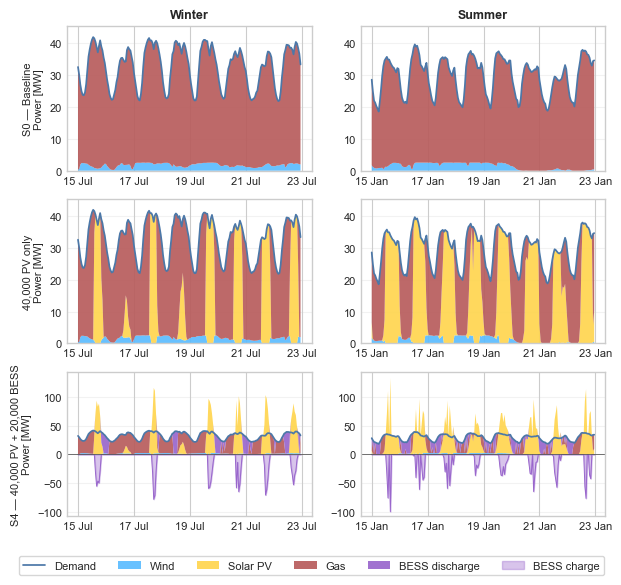

In [50]:
FOCUS_SCENARIOS = [
    "BASE",
    "CF_PV40000",
    "S4_PV40000_BESS20000",
]

FOCUS_ROW_LABELS = {
    "BASE": "S0 — Baseline",
    "CF_PV40000": "40,000 PV only",
    "S4_PV40000_BESS20000": "S4 — 40,000 PV + 20,000 BESS",
}

WINDOWS = {
    "Winter": (f"{MODEL_YEAR}-07-15", f"{MODEL_YEAR}-07-22"),
    "Summer": (f"{MODEL_YEAR}-01-15", f"{MODEL_YEAR}-01-22"),
}


def load_hourly(code: str) -> pd.DataFrame:
    path = HOURLY_DIR / f"{code}_2025.csv"
    if not path.exists():
        raise FileNotFoundError(f"Missing hourly output: {path}")
    return pd.read_csv(path, parse_dates=["timestamp"]).set_index("timestamp")


# Preload each row/season to calculate consistent y-limits across columns.
dispatch_data = {}
row_limits = {}

for code in FOCUS_SCENARIOS:
    dispatch_data[code] = {}
    row_positive_max = 0.0
    row_negative_min = 0.0

    for season, (start, end) in WINDOWS.items():
        h = load_hourly(code).loc[start:end].copy()
        dispatch_data[code][season] = h

        positive_stack = (
            h["wind_mw"].clip(lower=0)
            + h["solar_mw"].clip(lower=0)
            + h["thermal_mw"].clip(lower=0)
            + h["bess_discharge_mw"].clip(lower=0)
        )
        row_positive_max = max(
            row_positive_max,
            float(positive_stack.max()),
            float(h["demand_mw"].max()),
        )
        row_negative_min = min(
            row_negative_min,
            float((-h["bess_charge_mw"].clip(lower=0)).min()),
        )

    upper = max(5.0, row_positive_max * 1.08)
    lower = row_negative_min * 1.08 if row_negative_min < -1e-6 else 0.0
    row_limits[code] = (lower, upper)


fig, axes = plt.subplots(
    nrows=len(FOCUS_SCENARIOS),
    ncols=len(WINDOWS),
    figsize=(WORD_DOUBLE_COL_IN, 6.0),
    sharex=False,
)

season_names = list(WINDOWS.keys())

for row_i, code in enumerate(FOCUS_SCENARIOS):
    for col_i, season in enumerate(season_names):
        ax = axes[row_i, col_i]
        h = dispatch_data[code][season]

        ax.stackplot(
            h.index,
            h["wind_mw"].clip(lower=0),
            h["solar_mw"].clip(lower=0),
            h["thermal_mw"].clip(lower=0),
            h["bess_discharge_mw"].clip(lower=0),
            labels=["Wind", "Solar PV", "Gas", "BESS discharge"],
            colors=[
                TECH_COLORS["wind"],
                TECH_COLORS["solar"],
                TECH_COLORS["gas"],
                TECH_COLORS["bess"],
            ],
            alpha=0.92,
        )

        charge = h["bess_charge_mw"].clip(lower=0)
        if charge.max() > 1e-6:
            ax.fill_between(
                h.index,
                0,
                -charge,
                color=TECH_COLORS["bess"],
                alpha=0.38,
                label="BESS charge",
            )
            ax.plot(
                h.index,
                -charge,
                color=TECH_COLORS["bess"],
                linewidth=0.7,
            )

        ax.plot(
            h.index,
            h["demand_mw"],
            color=DEMAND_COLOR,
            linewidth=1.25,
            label="Demand",
            zorder=10,
        )

        ax.axhline(0, linewidth=0.6, color="0.35")
        ax.set_ylim(*row_limits[code])
        ax.grid(True, axis="y", alpha=GRID_ALPHA)
        ax.tick_params(axis="both", labelsize=FONT_SIZE_SMALL)

        # Compact date ticks for the two-column layout.
        ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))

        if row_i == 0:
            ax.set_title(season, fontsize=FONT_SIZE_LABEL, fontweight="bold")

        if col_i == 0:
            ax.set_ylabel(
                f"{FOCUS_ROW_LABELS[code]}\nPower [MW]",
                fontsize=FONT_SIZE_SMALL,
            )

# One common legend for the whole figure.
handles, labels = [], []
for ax in axes.flat:
    h_i, l_i = ax.get_legend_handles_labels()
    for handle, label in zip(h_i, l_i):
        if label not in labels:
            handles.append(handle)
            labels.append(label)

preferred_order = [
    "Demand",
    "Wind",
    "Solar PV",
    "Gas",
    "BESS discharge",
    "BESS charge",
]
ordered = [
    (handles[labels.index(label)], label)
    for label in preferred_order
    if label in labels
]

fig.legend(
    [h for h, _ in ordered],
    [l for _, l in ordered],
    loc="lower center",
    ncol=6,
    frameon=True,
    bbox_to_anchor=(0.5, -0.005),
)

#fig.suptitle(
#    "Seasonal dispatch — Punta Arenas 2025",
#    fontsize=FONT_SIZE_BASE + 1,
#)
fig.tight_layout(rect=[0, 0.055, 1, 0.97])

save_paper_figure(
    fig,
    "cinvie_2025_dispatch_winter_summer.png",
)
plt.show()


## 9. Optional household-economic layer

The PyPSA analysis above measures **system-level operational effects**. It does not yet represent household electricity bills, retail tariffs, net billing or behind-the-meter self-consumption.

A household-level economic layer should therefore be treated separately. The template below remains inactive until retail PV/BESS investment costs and tariff assumptions are specified.


In [49]:
# Optional simple-payback template — intentionally left inactive by default.
RUN_HOUSEHOLD_ECONOMICS = False

if RUN_HOUSEHOLD_ECONOMICS:
    # Replace with referenced Chile/Punta Arenas retail values.
    retail_pv_cost_clp = np.nan
    retail_pvbess_cost_clp = np.nan
    annual_household_saving_pv_clp = np.nan
    annual_household_saving_pvbess_clp = np.nan

    economics = pd.DataFrame({
        "system": ["PV", "PV+BESS"],
        "investment_clp": [retail_pv_cost_clp, retail_pvbess_cost_clp],
        "annual_saving_clp": [
            annual_household_saving_pv_clp,
            annual_household_saving_pvbess_clp,
        ],
    })
    economics["simple_payback_years"] = (
        economics["investment_clp"] / economics["annual_saving_clp"]
    )
    display(economics)
else:
    print(
        "Household economics disabled. "
        "System-level CINVIE results are available in scenario_summary."
    )


Household economics disabled. System-level CINVIE results are available in scenario_summary.


## 10. Files produced

- `tables/cinvie_2025_adoption_pathway_summary.csv`
- `tables/cinvie_2025_adoption_pathway_impacts.csv`
- `tables/cinvie_2025_incremental_bess_value.csv`
- `tables/cinvie_2025_pathway_scenario_key.csv`
- `hourly/<scenario>_2025.csv`
- `figures/cinvie_2025_adoption_pathway_system_impacts.png`
- `figures/cinvie_2025_incremental_bess_value.png`
- `figures/cinvie_2025_dispatch_winter_summer.png`

S5 is the only new simulation relative to the previous pathway notebook. Existing scenario exports are reused automatically when `OVERWRITE_RESULTS=False`.
